# X-means Klaszterezés - Bank Marketing Dataset
## Age és Balance alapján

### Célkitűzések:
- X-means klaszterezés automatikus klaszterszám meghatározással (kmin=2, kmax=10)
- 2 változó: **age** (életkor) és **balance** (egyenleg)
- BIC (Bayesian Information Criterion) alapú optimalizálás
- Validációs metrikák és összehasonlítás K-means-szel
- Klaszter profilozás és exportálás

## 1. Könyvtárak importálása

In [1]:
# Alapvető könyvtárak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn könyvtárak
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Matplotlib beállítások
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Könyvtárak sikeresen betöltve!")

✓ Könyvtárak sikeresen betöltve!


## 2. X-means Osztály Implementáció

In [2]:
class XMeans:
    #X-Means klaszterezési algoritmus implementáció.
    #Automatikusan meghatározza az optimális klaszterszámot BIC alapján.

    
    def __init__(self, kmin=2, kmax=8, random_state=42):
        """
        Paraméterek:
        -----------
        kmin : int
            Minimális klaszterszám (default: 2)
        kmax : int
            Maximális klaszterszám (default: 8)
        random_state : int
            Véletlenszám generátor seed (default: 42)
        """
        self.kmin = kmin
        self.kmax = kmax
        self.random_state = random_state
        self.labels_ = None
        self.cluster_centers_ = None
        self.n_clusters_ = None
        self.bic_scores_ = []
        
    def _calculate_bic(self, X, labels, centers):
        """
        BIC (Bayesian Information Criterion) számítása.
        Alacsonyabb BIC érték = jobb modell.
        """
        n_samples, n_features = X.shape
        n_clusters = len(centers)
        
        # Log-likelihood számítása
        variance = 0
        for i in range(n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                variance += np.sum((cluster_points - centers[i]) ** 2)
        
        variance = variance / (n_samples - n_clusters)
        
        if variance == 0:
            variance = 1e-10
            
        log_likelihood = -n_samples * np.log(2 * np.pi) / 2 - \
                        n_samples * n_features * np.log(variance) / 2 - \
                        (n_samples - n_clusters) / 2
        
        # BIC = log(n) * k - 2 * log_likelihood
        # k = paraméterek száma (középpontok + klaszter méretek)
        n_parameters = n_clusters * n_features + n_clusters
        bic = n_parameters * np.log(n_samples) - 2 * log_likelihood
        
        return bic
    
    def fit(self, X):
        """
        X-Means illesztése az adatokra.
        Minden k értéket tesztel kmin-től kmax-ig, és kiválasztja a legjobb BIC-t.
        """
        best_bic = np.inf
        best_k = self.kmin
        
        print("="*70)
        print("X-MEANS KLASZTEREZÉS FUTTATÁSA")
        print(f"Paraméterek: kmin={self.kmin}, kmax={self.kmax}, random_state={self.random_state}")
        print("="*70)
        
        # Próbáljuk ki az összes k értéket kmin-től kmax-ig
        for k in range(self.kmin, self.kmax + 1):
            # K-means++ inicializálás
            kmeans = KMeans(n_clusters=k, init='k-means++', random_state=self.random_state, n_init=50)
            labels = kmeans.fit_predict(X)
            centers = kmeans.cluster_centers_
            
            bic = self._calculate_bic(X, labels, centers)
            self.bic_scores_.append({'k': k, 'bic': bic})
            
            print(f"k = {k:2d}: BIC = {bic:>12,.2f}")
            
            # Keressük a legkisebb BIC értéket (alacsonyabb = jobb)
            if bic < best_bic:
                best_bic = bic
                best_k = k
                self.labels_ = labels
                self.cluster_centers_ = centers
        
        self.n_clusters_ = best_k
        print("="*70)
        print(f"✓ Optimális klaszterszám: k = {self.n_clusters_}")
        print(f"✓ Legjobb BIC érték: {best_bic:,.2f}")
        print("="*70)
        
        return self
    
    def predict(self, X):
        """
        Új adatpontok klaszterekhez rendelése.
        """
        distances = np.sqrt(((X[:, np.newaxis] - self.cluster_centers_) ** 2).sum(axis=2))
        return np.argmin(distances, axis=1)

print("✓ X-means osztály definiálva!")

✓ X-means osztály definiálva!


## 3. Adatok betöltése és előkészítése

In [3]:
# Adathalmaz beolvasása
root = r"bank+marketing\bank\bank-full.csv"
df = pd.read_csv(root, sep=';')

print("="*70)
print("ADATOK BETÖLTÉSE")
print("="*70)
print(f"Sorok száma: {len(df):,}")
print(f"Oszlopok száma: {len(df.columns)}")
print("\nElső 5 sor:")

# Winsorization (1-99 percentilis)
print("="*70)
print("WINSORIZATION")
print("="*70)
from scipy.stats.mstats import winsorize

df['balance_win'] = winsorize(df['balance'], limits=[0.01, 0.01])
print(df[['age', 'balance_win']].head())
print("\nStatisztikák:")
print(df[['age', 'balance_win']].describe())

ADATOK BETÖLTÉSE
Sorok száma: 45,211
Oszlopok száma: 17

Első 5 sor:
WINSORIZATION
   age  balance_win
0   58         2143
1   44           29
2   33            2
3   47         1506
4   33            1

Statisztikák:
                age   balance_win
count  45211.000000  45211.000000
mean      40.936210   1278.122691
std       10.618762   2249.412265
min       18.000000   -627.000000
25%       33.000000     72.000000
50%       39.000000    448.000000
75%       48.000000   1428.000000
max       95.000000  13165.000000


In [4]:
# Feature Selection: age és balance
features = ['age', 'balance_win']
X = df[features].copy()

print("\n" + "="*70)
print("FEATURE SELECTION ÉS NORMALIZÁLÁS")
print("="*70)
print(f"Kiválasztott változók: {features}")
print(f"Adatpontok száma: {len(X):,}")

# Normalizálás: StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(X)

print("\n✓ Adatok normalizálva (StandardScaler)!")
print(f"  data_scaled alakja: {data_scaled.shape}")
print(f"  Átlag: {data_scaled.mean(axis=0)}")
print(f"  Szórás: {data_scaled.std(axis=0)}")


FEATURE SELECTION ÉS NORMALIZÁLÁS
Kiválasztott változók: ['age', 'balance_win']
Adatpontok száma: 45,211

✓ Adatok normalizálva (StandardScaler)!
  data_scaled alakja: (45211, 2)
  Átlag: [2.11225020e-16 1.50875014e-17]
  Szórás: [1. 1.]


## 4. X-means Klaszterezés Futtatása

In [5]:
# X-means klaszterezés
xmeans = XMeans(kmin=2, kmax=8, random_state=42)
xmeans.fit(data_scaled)

# Címkék hozzáadása az eredeti adatokhoz
df['cluster'] = xmeans.labels_

# Középpontok visszaalakítása az eredeti skálára
centroids_original = scaler.inverse_transform(xmeans.cluster_centers_)

print("\n✓ Klaszter címkék hozzáadva az adathalmazhoz!")

X-MEANS KLASZTEREZÉS FUTTATÁSA
Paraméterek: kmin=2, kmax=8, random_state=42
k =  2: BIC =   150,472.93
k =  3: BIC =    91,950.97
k =  4: BIC =    72,264.48
k =  5: BIC =    48,460.92
k =  6: BIC =    33,189.79
k =  7: BIC =    20,161.52
k =  8: BIC =     8,678.64
✓ Optimális klaszterszám: k = 8
✓ Legjobb BIC érték: 8,678.64

✓ Klaszter címkék hozzáadva az adathalmazhoz!


## 5. BIC Értékek Vizualizációja

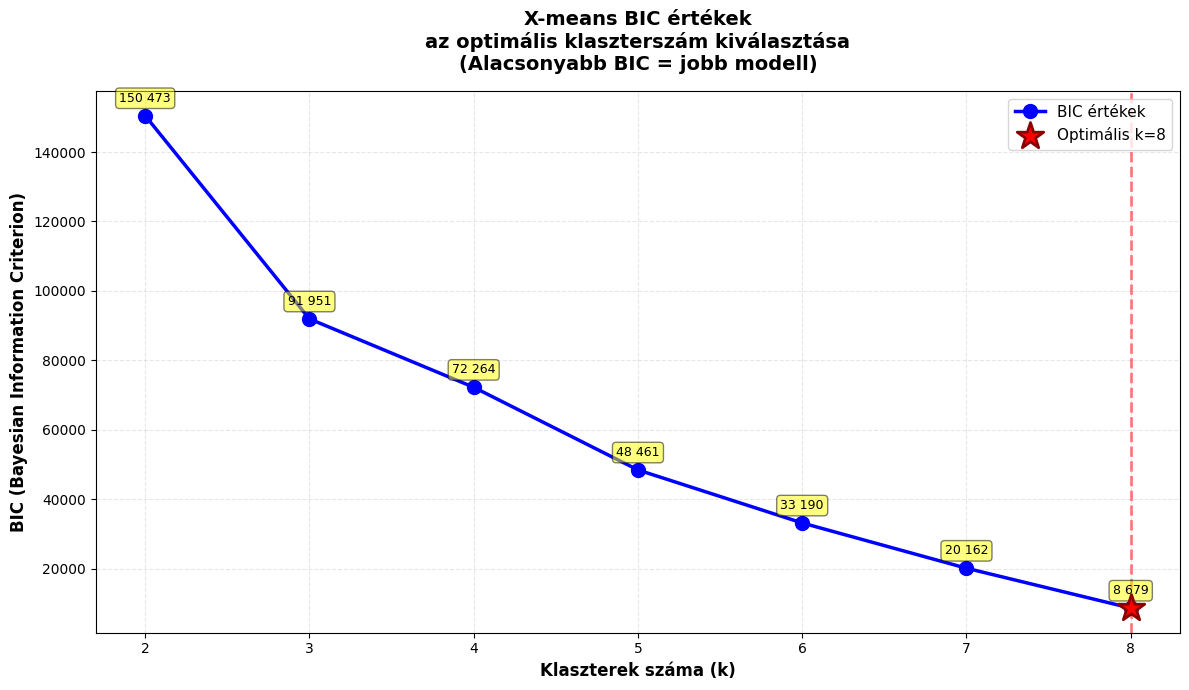

✓ BIC plot mentve: exports_xmeans/xmeans_bic_plot.png


In [6]:
# BIC értékek DataFrame-be
bic_df = pd.DataFrame(xmeans.bic_scores_)

# BIC plot
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(bic_df['k'], bic_df['bic'], 'bo-', linewidth=2.5, markersize=10, label='BIC értékek')

# Optimális k megjelölése
optimal_idx = bic_df['bic'].idxmin()
optimal_k = bic_df.loc[optimal_idx, 'k']
optimal_bic = bic_df.loc[optimal_idx, 'bic']

ax.scatter([optimal_k], [optimal_bic], color='red', s=400, zorder=5, 
          marker='*', edgecolors='darkred', linewidths=2, label=f'Optimális k={int(optimal_k)}')

ax.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.5, linewidth=2)

# Értékek annotálása
for idx, row in bic_df.iterrows():
    ax.annotate(f'{row["bic"]:,.0f}'.replace(',',' '), 
               (row['k'], row['bic']), 
               textcoords="offset points", 
               xytext=(0,10), 
               ha='center', 
               fontsize=9,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

ax.set_xlabel('Klaszterek száma (k)', fontsize=12, fontweight='bold')
ax.set_ylabel('BIC (Bayesian Information Criterion)', fontsize=12, fontweight='bold')
ax.set_title('X-means BIC értékek\naz optimális klaszterszám kiválasztása\n' + 
            '(Alacsonyabb BIC = jobb modell)', 
            fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(bic_df['k'])
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig('exports_xmeans/xmeans_bic_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ BIC plot mentve: exports_xmeans/xmeans_bic_plot.png")

## 6. Validációs Metrikák Számítása

In [ ]:
# Validációs metrikák számítása
silhouette = silhouette_score(data_scaled, xmeans.labels_)
davies_bouldin = davies_bouldin_score(data_scaled, xmeans.labels_)
calinski_harabasz = calinski_harabasz_score(data_scaled, xmeans.labels_)

# Metrikák DataFrame-be
metrics_df = pd.DataFrame({
    'Metrika': ['Optimális k', 'Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
    'Érték': [xmeans.n_clusters_, silhouette, davies_bouldin, calinski_harabasz],
    'Értelmezés': [
        'Klaszterek száma',
        'Magasabb = jobb (max: 1)',
        'Alacsonyabb = jobb',
        'Magasabb = jobb'
    ]
})

print("="*90)
print("VALIDÁCIÓS METRIKÁK - X-MEANS")
print("="*90)
print(metrics_df.to_string(index=False))
print("="*90)

# Exportálás CSV-be
metrics_df.to_csv('exports_xmeans/metrics_xmeans.csv', index=False, encoding='utf-8-sig')
print("\n✓ Metrikák exportálva: exports_xmeans/metrics_xmeans.csv")

VALIDÁCIÓS METRIKÁK - X-MEANS
                Metrika        Érték               Értelmezés
            Optimális k     8.000000         Klaszterek száma
       Silhouette Score     0.379300 Magasabb = jobb (max: 1)
   Davies-Bouldin Index     0.809467       Alacsonyabb = jobb
Calinski-Harabasz Index 42175.371448          Magasabb = jobb

✓ Metrikák exportálva: exports_xmeans/metrics_xmeans.csv


## 7. Klaszter Profilozás

In [22]:
# Klaszter profilozás
cluster_profile = []

for cluster_id in range(xmeans.n_clusters_):
    cluster_data = df[df['cluster'] == cluster_id]
    
    profile = {
        'Klaszter': cluster_id,
        'Átlag életkor': cluster_data['age'].mean(),
        'Szórás élet': cluster_data['age'].std(),
        'Átlag számlaegyenleg': cluster_data['balance_win'].mean(),
        'Szórás számlaegyenleg': cluster_data['balance_win'].std(),
        'Elemszám (db)': len(cluster_data),
        'Elemszám (%)': len(cluster_data) / len(df) * 100
    }
    cluster_profile.append(profile)

profile_df = pd.DataFrame(cluster_profile)

print("\n" + "="*100)
print("KLASZTER PROFILOZÁS - X-MEANS")
print("="*100)
print(profile_df.to_string(index=False))
print("="*100)

# Exportálás CSV-be
profile_df.to_csv('exports_xmeans/profil_xmeans.csv', index=False, encoding='utf-8-sig')
print("\n✓ Klaszter profilok exportálva: exports_xmeans/profil_xmeans.csv")


KLASZTER PROFILOZÁS - X-MEANS
 Klaszter  Átlag életkor  Szórás élet  Átlag számlaegyenleg  Szórás számlaegyenleg  Elemszám (db)  Elemszám (%)
        0      45.744438     2.537038            540.764097             696.087264           8495     18.789675
        1      29.472268     2.952725            452.094541             592.938425          11413     25.243857
        2      43.140108    10.686905          11046.948422            2000.439344           1299      2.873195
        3      34.426230     4.608746           4076.827554            1407.291046           3172      7.015992
        4      55.457372     3.148675            590.221314             707.727116           6850     15.151180
        5      52.299821     5.490098           4471.338248            1468.015138           2238      4.950123
        6      37.170974     2.271694            480.844586             610.716663          10990     24.308244
        7      73.107427     6.241520           1877.484085            17

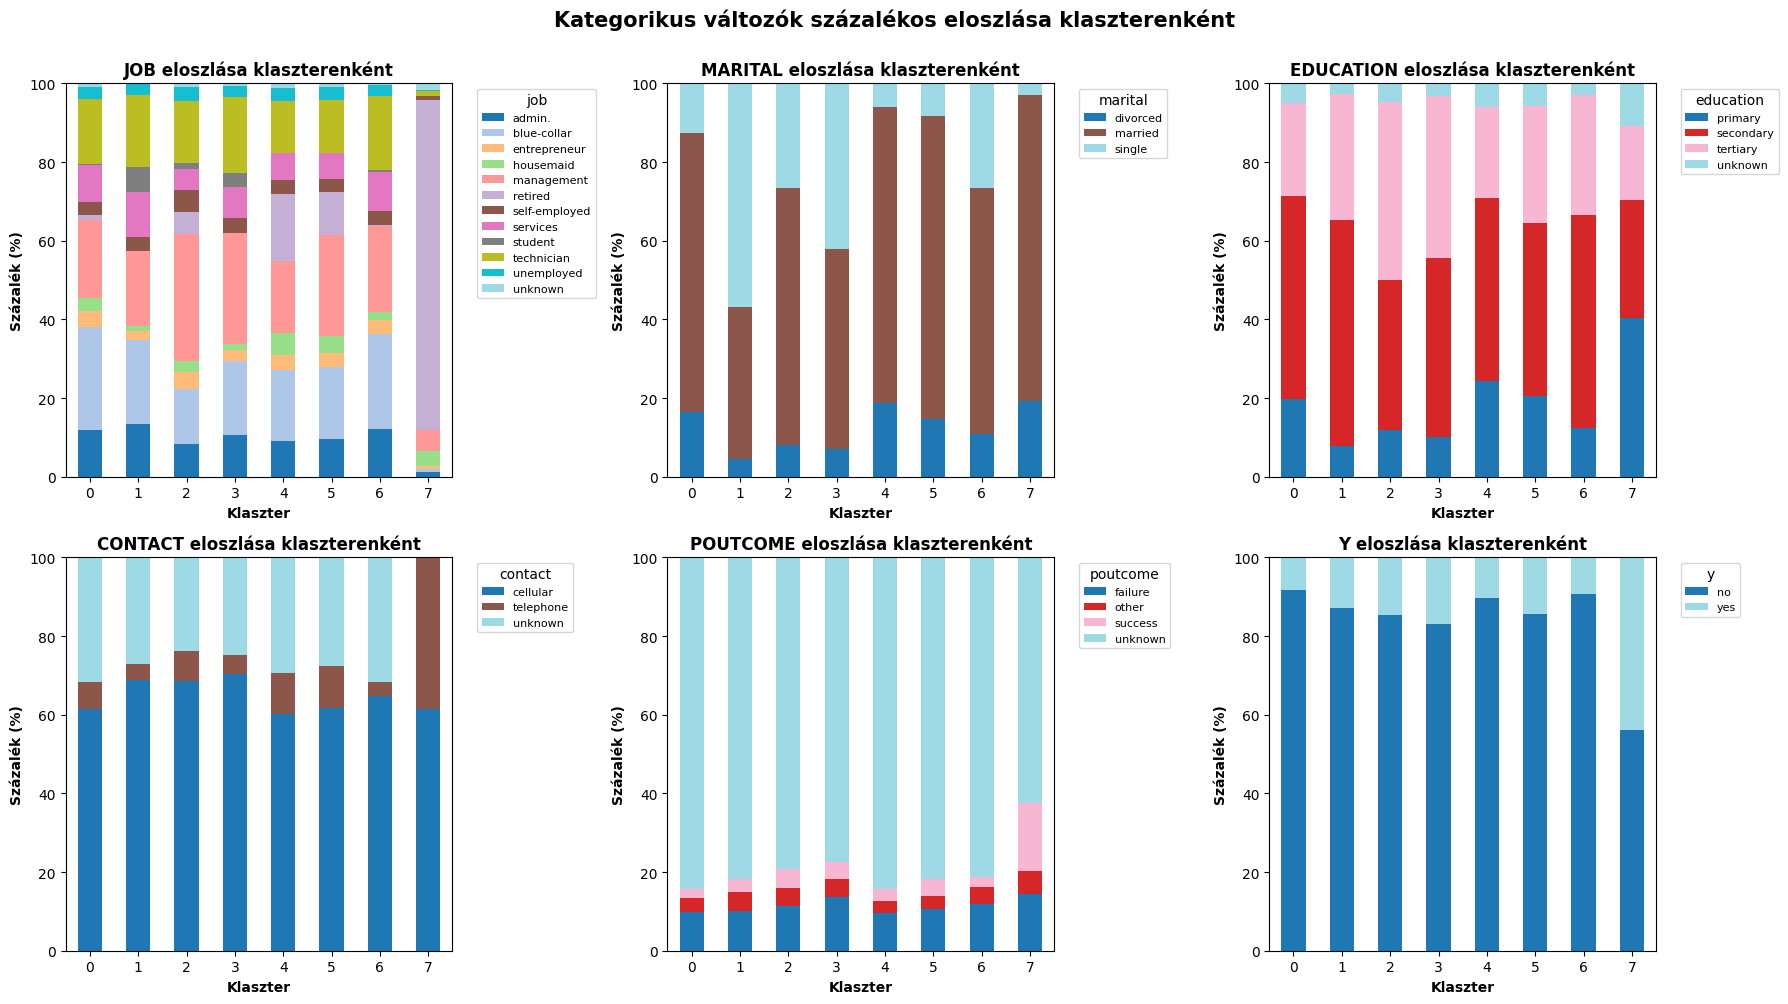

✓ Kategorikus eloszlások mentve: exports_xmeans/xmeans_categorical_distributions.png


In [26]:
# Vizualizáció - Stacked bar chart a fontosabb kategorikus változókra
important_categorical = ['job', 'marital', 'education', 'contact', 'poutcome', 'y']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(important_categorical):
    ax = axes[idx]
    crosstab = pd.crosstab(df['cluster'], df[col], normalize='index') * 100
    crosstab.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
    ax.set_title(f'{col.upper()} eloszlása klaszterenként', fontsize=12, fontweight='bold')
    ax.set_xlabel('Klaszter', fontsize=10, fontweight='bold')
    ax.set_ylabel('Százalék (%)', fontsize=10, fontweight='bold')
    ax.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylim([0, 100])

plt.suptitle('Kategorikus változók százalékos eloszlása klaszterenként', 
            fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('exports_xmeans/xmeans_categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Kategorikus eloszlások mentve: exports_xmeans/xmeans_categorical_distributions.png")

## 8. Centroidok Exportálása

In [23]:
# Centroidok DataFrame
centroids_df = pd.DataFrame(
    centroids_original,
    columns=['Átlag életkor (év)', 'Átlag egyenleg (€)']
)
centroids_df.index = [f'Cluster_{i}' for i in range(xmeans.n_clusters_)]

# Klaszter méret hozzáadása
cluster_sizes = df['cluster'].value_counts().sort_index()
centroids_df['Ügyfelek száma'] = cluster_sizes.values
centroids_df['Arány (%)'] = (centroids_df['Ügyfelek száma'] / len(df) * 100).round(2)

print("\n" + "="*90)
print("KLASZTER CENTROIDOK - X-MEANS (eredeti skálán)")
print("="*90)
print(centroids_df.to_string())
print("="*90)

# Exportálás CSV-be
centroids_df.to_csv('exports_xmeans/centroids_xmeans.csv', encoding='utf-8-sig')
print("\n✓ Centroidok exportálva: exports_xmeans/centroids_xmeans.csv")


KLASZTER CENTROIDOK - X-MEANS (eredeti skálán)
           Átlag életkor (év)  Átlag egyenleg (€)  Ügyfelek száma  Arány (%)
Cluster_0           45.743170          540.081606            8495      18.79
Cluster_1           29.472397          451.914826           11413      25.24
Cluster_2           43.143077        11044.380000            1299       2.87
Cluster_3           34.409650         4076.379376            3172       7.02
Cluster_4           55.464536          589.451547            6850      15.15
Cluster_5           52.275801         4461.202847            2238       4.95
Cluster_6           37.170945          480.172401           10990      24.31
Cluster_7           73.145333         1886.409333             754       1.67

✓ Centroidok exportálva: exports_xmeans/centroids_xmeans.csv


## 9. Scatter Plot - Életkor és számlaegyenleg

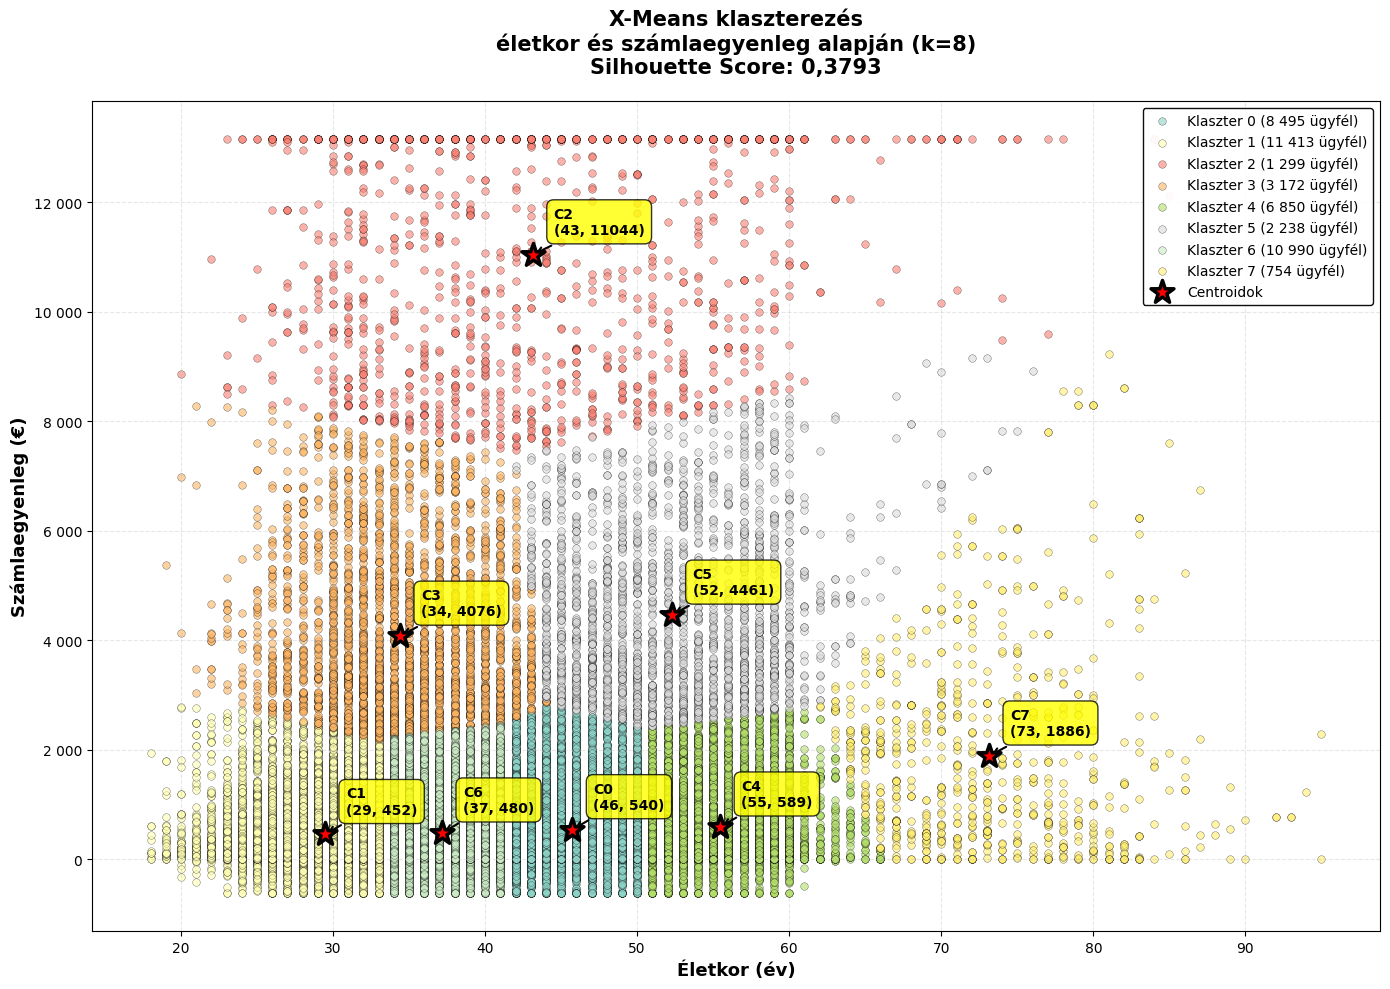

✓ Scatter plot mentve: exports_xmeans/xmeans_scatter_plot.png


In [24]:
# Scatter plot - Életkor és számlaegyenleg színkódolt klaszterekkel
fig, ax = plt.subplots(figsize=(14, 10))

# Színek definiálása
colors = plt.cm.Set3(np.linspace(0, 1, xmeans.n_clusters_))

# Klaszterek ábrázolása
for cluster_id in range(xmeans.n_clusters_):
    cluster_data = df[df['cluster'] == cluster_id]
    ax.scatter(cluster_data['age'], cluster_data['balance_win'], 
              label=f'Klaszter {cluster_id} ({len(cluster_data):,} ügyfél)'.replace(',',' '), 
              alpha=0.6, s=30, c=[colors[cluster_id]], edgecolors='black', linewidths=0.3)

# Centroidok ábrázolása
ax.scatter(centroids_original[:, 0], centroids_original[:, 1], 
          marker='*', s=300, c='red', edgecolors='black', linewidths=2.5, 
          label='Centroidok', zorder=10)

# Centroid címkék
for i, (x, y) in enumerate(centroids_original):
    ax.annotate(f'C{i}\n({x:.0f}, {y:.0f})', 
               (x, y), 
               xytext=(15, 15), 
               textcoords='offset points',
               fontsize=10,
               fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8, edgecolor='black'),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1.5))

ax.set_xlabel('Életkor (év)', fontsize=13, fontweight='bold')
ax.set_ylabel('Számlaegyenleg (€)', fontsize=13, fontweight='bold')
ax.set_title(f'X-Means klaszterezés\néletkor és számlaegyenleg alapján (k={xmeans.n_clusters_})\n' + 
            f'Silhouette Score: {silhouette:.4f}'.replace('.',','), 
            fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3, linestyle='--')

# Y tengely formázása
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', ' ')))

plt.tight_layout()
plt.savefig('exports_xmeans/xmeans_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Scatter plot mentve: exports_xmeans/xmeans_scatter_plot.png")

## 11. Összefoglaló és Következtetések

In [25]:
print("\n" + "="*100)
print("X-MEANS KLASZTEREZÉS - VÉGSŐ ÖSSZEFOGLALÓ")
print("="*100)

print(f"\n1. MÓDSZERTAN:")
print(f"   - Algoritmus: X-means (BIC-alapú optimalizálás)")
print(f"   - Vizsgált klaszterszámok: kmin={xmeans.kmin}, kmax={xmeans.kmax}")
print(f"   - Inicializálás: K-means++")
print(f"   - Random state: {xmeans.random_state}")
print(f"   - Használt változók: age, balance_win")
print(f"   - Normalizálás: StandardScaler")

print(f"\n2. X-MEANS EREDMÉNYEK:")
print(f"   - Automatikusan választott k: {xmeans.n_clusters_}")
print(f"   - BIC érték: {optimal_bic:,.2f}")
print(f"   - Silhouette Score: {silhouette:.4f}")
print(f"   - Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"   - Calinski-Harabasz Index: {calinski_harabasz:.2f}")

print(f"\n3. KLASZTEREK MÉRETE:")
for cluster_id in range(xmeans.n_clusters_):
    count = (df['cluster'] == cluster_id).sum()
    percentage = count / len(df) * 100
    avg_age = df[df['cluster'] == cluster_id]['age'].mean()
    avg_balance = df[df['cluster'] == cluster_id]['balance_win'].mean()
    print(f"   Klaszter {cluster_id}: {count:>6,} ügyfél ({percentage:>5.1f}%) - "
          f"Átlag kor: {avg_age:.0f} év, Átlag egyenleg: {avg_balance:,.0f} €")

print(f"\n5. EXPORTÁLT FÁJLOK:")
print(f"   CSV fájlok:")
print(f"   - ábrák/metrics_xmeans.csv - Validációs metrikák")
print(f"   - ábrák/profil_xmeans.csv - Klaszter profilok")
print(f"   - ábrák/centroids_xmeans.csv - Centroidok koordinátái")
print(f"   \n   PNG ábrák:")
print(f"   - ábrák/xmeans_bic_plot.png - BIC értékek")
print(f"   - ábrák/xmeans_scatter_plot.png - Scatter plot")

print(f"\n6. KÖVETKEZTETÉSEK:")
print(f"   Az X-means algoritmus automatikusan {xmeans.n_clusters_} klasztert azonosított")
print(f"   a BIC (Bayesian Information Criterion) alapján.")
print(f"   ")
print(f"   Az X-means előnye: nincs szükség manuális k meghatározásra,")
print(f"   az algoritmus automatikusan megtalálja az optimális klaszterszámot.")

print("\n" + "="*100)
print("✓ X-MEANS KLASZTEREZÉS SIKERESEN BEFEJEZVE!")
print("="*100)


X-MEANS KLASZTEREZÉS - VÉGSŐ ÖSSZEFOGLALÓ

1. MÓDSZERTAN:
   - Algoritmus: X-means (BIC-alapú optimalizálás)
   - Vizsgált klaszterszámok: kmin=2, kmax=8
   - Inicializálás: K-means++
   - Random state: 42
   - Használt változók: age, balance_win
   - Normalizálás: StandardScaler

2. X-MEANS EREDMÉNYEK:
   - Automatikusan választott k: 8
   - BIC érték: 8,678.64
   - Silhouette Score: 0.3793
   - Davies-Bouldin Index: 0.8095
   - Calinski-Harabasz Index: 42175.37

3. KLASZTEREK MÉRETE:
   Klaszter 0:  8,495 ügyfél ( 18.8%) - Átlag kor: 46 év, Átlag egyenleg: 541 €
   Klaszter 1: 11,413 ügyfél ( 25.2%) - Átlag kor: 29 év, Átlag egyenleg: 452 €
   Klaszter 2:  1,299 ügyfél (  2.9%) - Átlag kor: 43 év, Átlag egyenleg: 11,047 €
   Klaszter 3:  3,172 ügyfél (  7.0%) - Átlag kor: 34 év, Átlag egyenleg: 4,077 €
   Klaszter 4:  6,850 ügyfél ( 15.2%) - Átlag kor: 55 év, Átlag egyenleg: 590 €
   Klaszter 5:  2,238 ügyfél (  5.0%) - Átlag kor: 52 év, Átlag egyenleg: 4,471 €
   Klaszter 6: 10,990